# TypiClust (TPCRP) - CIFAR-10


### config

In [ ]:
BUDGETS = [10, 20, 30, 40, 50, 60, 100, 150, 200, 250, 300]

N_REPEATS = 10
CLF_EPOCHS = 200
CLF_LR = 0.025
WEIGHT_DECAY = 5e-4

SIMCLR_EPOCHS = 500
SIMCLR_BATCH = 512
SIMCLR_LR = 0.4
TEMPERATURE = 0.5
PROJECTION_DIM = 128

K_NEIGHBOURS = 20
MAX_CLUSTERS = 500
MIN_CLUSTER_SIZE = 5

DATA_DIR = "../data"
CKPT_PATH = "../models/simclr_cifar10_500epochs.pth" # model 
EMB_PATH = "../embeddings/embeddings_500.npy"
LBL_PATH = "../labels/labels_500.npy"


### imports

In [ ]:
import os, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.neighbors import NearestNeighbors
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Machines or Kaggle or Colab
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

Path(DATA_DIR).mkdir(parents=True, exist_ok=True)
CIFAR_MEAN = [0.4914, 0.4822, 0.4465]
CIFAR_STD = [0.2023, 0.1994, 0.2010]
CLASSES = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

print("device: ", DEVICE)



Device: mps


### SimCLR model



In [3]:
class SimCLRAugmentation:
    def __init__(self, size=32):
        self.t = T.Compose(
            [
                T.RandomResizedCrop(size=size, scale=(0.2, 1.0)),
                T.RandomHorizontalFlip(),
                T.RandomApply([T.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8),
                T.RandomGrayscale(p=0.2),
                T.ToTensor(),
                T.Normalize(CIFAR_MEAN, CIFAR_STD),
            ]
        )

    def __call__(self, x):
        return self.t(x), self.t(x)

class SimCLRModel(nn.Module):
    def __init__(self, proj_dim=128):
        super().__init__()
        backbone = torchvision.models.resnet18(weights=None)
        self.embed_dim = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.encoder = backbone
        self.projector = nn.Sequential(
            nn.Linear(self.embed_dim, self.embed_dim),
            nn.ReLU(inplace=True),
            nn.Linear(self.embed_dim, proj_dim),
        )

    def forward(self, x):
        return F.normalize(self.projector(self.encoder(x)), dim=1)

    @torch.no_grad()
    def embed(self, x):
        return F.normalize(self.encoder(x), dim=1)

class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super().__init__()
        self.T = temperature

    def forward(self, z1, z2):
        B = z1.size(0)
        z = torch.cat([z1, z2], dim=0)
        sim = torch.mm(z, z.T) / self.T
        sim.fill_diagonal_(float("-inf"))
        labels = torch.cat([torch.arange(B, 2 * B), torch.arange(B)]).to(z.device)
        return F.cross_entropy(sim, labels)

model = SimCLRModel(proj_dim=PROJECTION_DIM).to(DEVICE)
print("model ready, params:", sum(p.numel() for p in model.parameters()))


SimCLR model ready. Embed dim: 512


In [ ]:
if os.path.exists(CKPT_PATH):
    
    ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
    model.load_state_dict(ckpt["model"])
    print("checkpoint loaded")

else:
    print("training simclr...")
    simclr_dataset = torchvision.datasets.CIFAR10(
        root=DATA_DIR, train=True, download=True, transform=SimCLRAugmentation(size=32)
    )
    simclr_loader = torch.utils.data.DataLoader(
        simclr_dataset,
        batch_size=SIMCLR_BATCH,
        shuffle=True,
        num_workers=0,
        pin_memory=False,
        drop_last=True,
    )
    criterion = NTXentLoss(temperature=TEMPERATURE)
    optimizer = torch.optim.SGD(model.parameters(), lr=SIMCLR_LR, momentum=0.9, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=SIMCLR_EPOCHS)
    t0 = time.time()
    for epoch in range(SIMCLR_EPOCHS):
        model.train()
        epoch_loss = 0.0
        for (v1, v2), _ in simclr_loader:
            z1, z2 = model(v1.to(DEVICE)), model(v2.to(DEVICE))
            loss = criterion(z1, z2)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        scheduler.step()
        if (epoch + 1) % 20 == 0:
            print(
                f"Epoch {epoch+1}/{SIMCLR_EPOCHS}  "
                f"loss={epoch_loss/len (simclr_loader ):.4f}  "
                f"elapsed={(time.time ()-t0 )/60:.1f} min"
            )
        if (epoch + 1) % 50 == 0 or (epoch + 1) == SIMCLR_EPOCHS:
            torch.save(
                {"epoch":epoch, "model":model.state_dict(), "optim":optimizer.state_dict()},
                CKPT_PATH,
            )
    print("done")


Loaded SimCLR checkpoint from ../models/simclr_cifar10_500epochs.pth
Trained for 500 epochs


In [ ]:
if os.path.exists(EMB_PATH) and os.path.exists(LBL_PATH):
    embeddings = np.load(EMB_PATH)
    labels = np.load(LBL_PATH)
    print("loaded:", embeddings.shape)
else:
    print("extracting embeddings...")
    embed_dataset = torchvision.datasets.CIFAR10(
        root=DATA_DIR,
        train=True,
        download=False,
        transform=T.Compose([T.ToTensor(), T.Normalize(CIFAR_MEAN, CIFAR_STD)]),
    )
    embed_loader = torch.utils.data.DataLoader(
        embed_dataset, batch_size=512, shuffle=False, num_workers=0
    )
    model.eval()
    embs, lbls_list = [], []
    with torch.no_grad():
        for imgs, lbls in tqdm(embed_loader):
            embs.append(model.embed(imgs.to(DEVICE)).cpu().numpy())
            lbls_list.append(lbls.numpy())
    embeddings = np.concatenate(embs)
    labels = np.concatenate(lbls_list)
    np.save(EMB_PATH, embeddings)
    np.save(LBL_PATH, labels)
    print("saved, shape:", embeddings.shape)


Loaded cached embeddings: (50000, 512)


### SCAN clustering

In [ ]:
SCAN_BUDGETS = [150, 200, 250]
SCAN_DIR = "../scan_assignments"
SCAN_EPOCHS = 100
SCAN_LR = 1e-4
SCAN_BATCH = 512
SCAN_K_NEIGHBORS = 20
SCAN_ENT_WEIGHT = 5.0
SCAN_WEIGHT_DECAY = 1e-4

os.makedirs(SCAN_DIR, exist_ok=True)


SCAN assignments will be saved to: /Users/mark/Documents/GitHub/ML_CW2/scan_assignments


In [7]:
class SCANDataset(torch.utils.data.Dataset):
    def __init__(self, raw_dataset, neighbor_indices, transform):
        self.ds = raw_dataset
        self.nbrs = neighbor_indices
        self.transform = transform

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, i):
        img_i, _ = self.ds[i]
        j = int(np.random.choice(self.nbrs[i]))
        img_j, _ = self.ds[j]
        return self.transform(img_i), self.transform(img_j)

scan_aug = T.Compose(
    [
        T.RandomResizedCrop(size=32, scale=(0.2, 1.0)),
        T.RandomHorizontalFlip(),
        T.RandomApply([T.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8),
        T.RandomGrayscale(p=0.2),
        T.ToTensor(),
        T.Normalize(CIFAR_MEAN, CIFAR_STD),
    ]
)

scan_plain = T.Compose([T.ToTensor(), T.Normalize(CIFAR_MEAN, CIFAR_STD)])

raw_cifar10 = torchvision.datasets.CIFAR10(
    root=DATA_DIR, train=True, download=False, transform=None
)
plain_cifar10 = torchvision.datasets.CIFAR10(
    root=DATA_DIR, train=True, download=False, transform=scan_plain
)

def train_scan_e2e(
    neighbor_indices,
    n_clusters,
    epochs=SCAN_EPOCHS,
    lr=SCAN_LR,
    weight_decay=SCAN_WEIGHT_DECAY,
    batch_size=SCAN_BATCH,
    entropy_weight=SCAN_ENT_WEIGHT,
    seed=SEED,
):
    torch.manual_seed(seed)
    np.random.seed(seed)

    ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
    _tmp = SimCLRModel(proj_dim=PROJECTION_DIM).to(DEVICE)
    _tmp.load_state_dict(ckpt["model"])
    encoder = _tmp.encoder
    del _tmp

    head = nn.Linear(512, n_clusters, bias=False).to(DEVICE)

    optimizer = torch.optim.Adam(
        list(encoder.parameters()) + list(head.parameters()), lr=lr, weight_decay=weight_decay
    )

    dataset = SCANDataset(raw_cifar10, neighbor_indices, scan_aug)
    loader = torch.utils.data.DataLoader(
        dataset, batch_size=batch_size, shuffle=True, num_workers=0, drop_last=True
    )

    encoder.train()
    head.train()
    for epoch in range(epochs):
        total = 0.0
        for anchor, neighbor in loader:
            anchor, neighbor = anchor.to(DEVICE), neighbor.to(DEVICE)

            p_a = F.softmax(head(encoder(anchor)), dim=1)
            p_n = F.softmax(head(encoder(neighbor)), dim=1)

            consistency = -(p_a * torch.log(p_n + 1e-8)).sum(dim=1).mean()
            mean_p = p_a.mean(dim=0)
            entropy = -(mean_p * torch.log(mean_p + 1e-8)).sum()
            loss = consistency - entropy_weight * entropy

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total += loss.item()

        if (epoch + 1) % 25 == 0:
            print(f"    Epoch {epoch+1:3d}/{epochs}  loss={total/len (loader ):.4f}")

    encoder.eval()
    head.eval()
    plain_loader = torch.utils.data.DataLoader(
        plain_cifar10, batch_size=512, shuffle=False, num_workers=0
    )
    logits_list = []
    with torch.no_grad():
        for imgs, _ in plain_loader:
            logits_list.append(head(encoder(imgs.to(DEVICE))).cpu())
    assignments = torch.cat(logits_list).argmax(dim=1).numpy()

    del encoder, head
    torch.cuda.empty_cache() if torch.cuda.is_available() else None
    return assignments

print("SCAN end-to-end helpers defined.")
print("Backbone will be loaded from:", CKPT_PATH)


/Users/mark/Documents/GitHub/ML_CW2/venv/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


SCAN end-to-end helpers defined.
Backbone will be loaded from: ../models/simclr_cifar10_500epochs.pth


In [8]:
print("computing KNN...")
scan_nbrs = NearestNeighbors(
    n_neighbors=SCAN_K_NEIGHBORS + 1, algorithm="auto", metric="euclidean", n_jobs=-1
)
scan_nbrs.fit(embeddings)
_, _scan_nb_idx = scan_nbrs.kneighbors(embeddings)
scan_neighbor_indices = _scan_nb_idx[:, 1:]

for B in SCAN_BUDGETS:
    K = min(B, MAX_CLUSTERS)
    save_path = f"{SCAN_DIR}/scan_K{K}.npy"
    if os.path.exists(save_path):
        print(f"K={K} already done")
        continue
    print(f"training SCAN K={K}...")
    t0 = time.time()
    asgn = train_scan_e2e(scan_neighbor_indices, n_clusters=K, seed=SEED)
    np.save(save_path, asgn)
    n_used = len(np.unique(asgn))
    print(f"  done, saved to {save_path}")

print("all SCAN assignments ready")


Pre-computing KNN for SCAN (K=20) over 50k points...
KNN ready. Shape: (50000, 20)

Training SCAN head  K=150 clusters ...
    Epoch  25/100  loss=-21.8264
    Epoch  50/100  loss=-22.2621
    Epoch  75/100  loss=-22.4710
    Epoch 100/100  loss=-22.4681
  Done 48.4 min  |  clusters used 150/150  →  ../scan_assignments/scan_K150.npy

Training SCAN head  K=200 clusters ...
    Epoch  25/100  loss=-23.0005
    Epoch  50/100  loss=-23.4279
    Epoch  75/100  loss=-23.5165
    Epoch 100/100  loss=-23.5868
  Done 48.9 min  |  clusters used 200/200  →  ../scan_assignments/scan_K200.npy

Training SCAN head  K=250 clusters ...
    Epoch  25/100  loss=-23.8355


KeyboardInterrupt: 

### TPCRP selection



In [9]:
class TPCRP:

    def __init__(
        self,
        embeddings,
        budget,
        k_neighbours=20,
        max_clusters=500,
        min_cluster_size=5,
        labeled_indices=None,
    ):
        self.embeddings = embeddings.astype(np.float32)
        self.budget = budget
        self.k_neighbours = k_neighbours
        self.max_clusters = max_clusters
        self.min_cluster_size = min_cluster_size
        self.labeled_set = set(labeled_indices.tolist()) if labeled_indices is not None else set()

        self.global_typicality = self._compute_global_typicality()

    def _compute_global_typicality(self):
        print(
            f"Computing global typicality (k={self.k_neighbours}) "
            f"over {len (self.embeddings ):,} points..."
        )
        k = min(self.k_neighbours, len(self.embeddings) - 1)
        nbrs = NearestNeighbors(n_neighbors=k + 1, algorithm="auto", metric="euclidean", n_jobs=-1)
        nbrs.fit(self.embeddings)
        dists, _ = nbrs.kneighbors(self.embeddings)
        mean_dist = dists[:, 1:].mean(axis=1)
        typicality = 1.0 / (mean_dist + 1e-8)
        print(
            f"Typicality computed. " f"Range: [{typicality.min ():.3f}, {typicality.max ():.3f}]"
        )
        return typicality

    def _cluster(self):
        K = min(len(self.labeled_set) + self.budget, self.max_clusters)
        print(f"K-means: K={K} clusters on {len (self.embeddings ):,} points...")
        if K <= 50:
            km = KMeans(n_clusters=K, random_state=SEED, n_init=10, max_iter=300)
        else:
            km = MiniBatchKMeans(
                n_clusters=K, random_state=SEED, n_init=5, batch_size=2048, max_iter=300
            )
        assignments = km.fit_predict(self.embeddings)
        print(f"Clustering done.")
        return assignments, K

    def select(self):
        assignments, K = self._cluster()

        covered = {assignments[i] for i in self.labeled_set}

        sizes = np.bincount(assignments, minlength=K)
        uncovered = sorted([c for c in range(K) if c not in covered], key=lambda c: -sizes[c])

        selected = []
        for cid in uncovered:
            if len(selected) >= self.budget:
                break

            c_idxs = np.where(assignments == cid)[0]
            c_idxs = c_idxs[~np.isin(c_idxs, list(self.labeled_set))]

            if len(c_idxs) < self.min_cluster_size:
                continue

            cluster_typicality = self.global_typicality[c_idxs]
            best = c_idxs[np.argmax(cluster_typicality)]
            selected.append(int(best))

        return np.array(selected)

print("TPCRP class defined.")


TPCRP class defined.


### classifier training

In [10]:
class LabeledSubset(torch.utils.data.Dataset):
    def __init__(self, base, indices):
        self.base, self.indices = base, indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        return self.base[self.indices[i]]

train_transform = T.Compose(
    [
        T.RandomCrop(32, padding=4),
        T.RandomHorizontalFlip(),
        T.ToTensor(),
        T.Normalize(CIFAR_MEAN, CIFAR_STD),
    ]
)
test_transform = T.Compose(
    [
        T.ToTensor(),
        T.Normalize(CIFAR_MEAN, CIFAR_STD),
    ]
)

full_train = torchvision.datasets.CIFAR10(
    root=DATA_DIR, train=True, download=False, transform=train_transform
)
test_set = torchvision.datasets.CIFAR10(
    root=DATA_DIR, train=False, download=False, transform=test_transform
)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=512, shuffle=False, num_workers=0)

def train_and_eval(selected_indices, epochs=CLF_EPOCHS, lr=CLF_LR, wd=WEIGHT_DECAY, seed=SEED):
    torch.manual_seed(seed)
    np.random.seed(seed)

    subset = LabeledSubset(full_train, selected_indices)
    _sampler = torch.utils.data.RandomSampler(
        subset, replacement=True, num_samples=max(len(subset), 128)
    )
    loader = torch.utils.data.DataLoader(
        subset, batch_size=128, sampler=_sampler, num_workers=0, drop_last=False
    )

    net = torchvision.models.resnet18(weights=None)
    net.fc = nn.Linear(net.fc.in_features, 10)
    net = net.to(DEVICE)

    optim = torch.optim.SGD(net.parameters(), lr=lr, momentum=0.9, nesterov=True, weight_decay=wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=epochs)
    crit = nn.CrossEntropyLoss()

    for _ in range(epochs):
        net.train()
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            optim.zero_grad()
            crit(net(imgs), lbls).backward()
            optim.step()
        sched.step()

    net.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            correct += (net(imgs).argmax(1) == lbls).sum().item()
            total += lbls.size(0)
    return 100.0 * correct / total

print("Evaluation helpers ready.")


/Users/mark/Documents/GitHub/ML_CW2/venv/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Evaluation helpers ready.


### budget sweep

In [11]:
print("computing typicality...")
k = min(K_NEIGHBOURS, len(embeddings) - 1)
nbrs = NearestNeighbors(n_neighbors=k + 1, algorithm="auto", metric="euclidean", n_jobs=-1)
nbrs.fit(embeddings)
dists, _ = nbrs.kneighbors(embeddings)
GLOBAL_TYPICALITY = 1.0 / (dists[:, 1:].mean(axis=1) + 1e-8)
print(embeddings.shape, GLOBAL_TYPICALITY.shape) # sanity check


Pre-computing global typicality (done once, reused for all budgets)...
Global typicality ready. Shape: (50000,)


In [12]:
results = {b: {"tpcrp":[], "random":[]} for b in BUDGETS}

for budget in BUDGETS:
    print(f"budget {budget}")
    for rep in range(N_REPEATS):
        rep_seed = SEED + rep * 100
        np.random.seed(rep_seed)
        torch.manual_seed(rep_seed)

        K = min(budget, MAX_CLUSTERS)
        if K <= 50:
            km = KMeans(n_clusters=K, random_state=rep_seed, n_init=10, max_iter=300)
        else:
            km = MiniBatchKMeans(n_clusters=K, random_state=rep_seed, n_init=5, batch_size=2048)
        assignments = km.fit_predict(embeddings)

        sizes = np.bincount(assignments, minlength=K)
        clust_order = np.argsort(-sizes) # biggest clusters first

        tpcrp_idx = []
        for cid in clust_order:
            if len(tpcrp_idx) >= budget:
                break
            c_idxs = np.where(assignments == cid)[0]
            if len(c_idxs) < MIN_CLUSTER_SIZE:
                continue
            best = c_idxs[np.argmax(GLOBAL_TYPICALITY[c_idxs])]
            tpcrp_idx.append(int(best))
        tpcrp_idx = np.array(tpcrp_idx)

        tpcrp_acc = train_and_eval(tpcrp_idx, seed=rep_seed)
        results[budget]["tpcrp"].append(tpcrp_acc)

        ridx = np.random.choice(len(embeddings), budget, replace=False)
        rand_acc = train_and_eval(ridx, seed=rep_seed)
        results[budget]["random"].append(rand_acc)

        print(f"  rep {rep+1}: tpcrp={tpcrp_acc:.1f}%  random={rand_acc:.1f}%")

print("done")



══ Budget B=50 (5 per class) ══════════════════════
  Rep  1/10  TPCRP=26.09%  Random=20.90%  Δ=+5.19%
  Rep  2/10  TPCRP=27.76%  Random=19.48%  Δ=+8.28%
  Rep  3/10  TPCRP=25.21%  Random=17.58%  Δ=+7.63%
  Rep  4/10  TPCRP=26.23%  Random=20.23%  Δ=+6.00%
  Rep  5/10  TPCRP=25.53%  Random=22.02%  Δ=+3.51%
  Rep  6/10  TPCRP=27.46%  Random=21.43%  Δ=+6.03%
  Rep  7/10  TPCRP=27.97%  Random=19.01%  Δ=+8.96%
  Rep  8/10  TPCRP=26.76%  Random=20.85%  Δ=+5.91%
  Rep  9/10  TPCRP=27.09%  Random=19.39%  Δ=+7.70%
  Rep 10/10  TPCRP=25.25%  Random=22.20%  Δ=+3.05%

══ Budget B=100 (10 per class) ══════════════════════
  Rep  1/10  TPCRP=28.97%  Random=24.32%  Δ=+4.65%
  Rep  2/10  TPCRP=30.00%  Random=24.23%  Δ=+5.77%
  Rep  3/10  TPCRP=30.38%  Random=23.69%  Δ=+6.69%
  Rep  4/10  TPCRP=29.32%  Random=24.41%  Δ=+4.91%
  Rep  5/10  TPCRP=29.40%  Random=25.64%  Δ=+3.76%
  Rep  6/10  TPCRP=28.97%  Random=24.19%  Δ=+4.78%
  Rep  7/10  TPCRP=31.29%  Random=22.58%  Δ=+8.71%
  Rep  8/10  TPCRP=30.14%

### results!!!

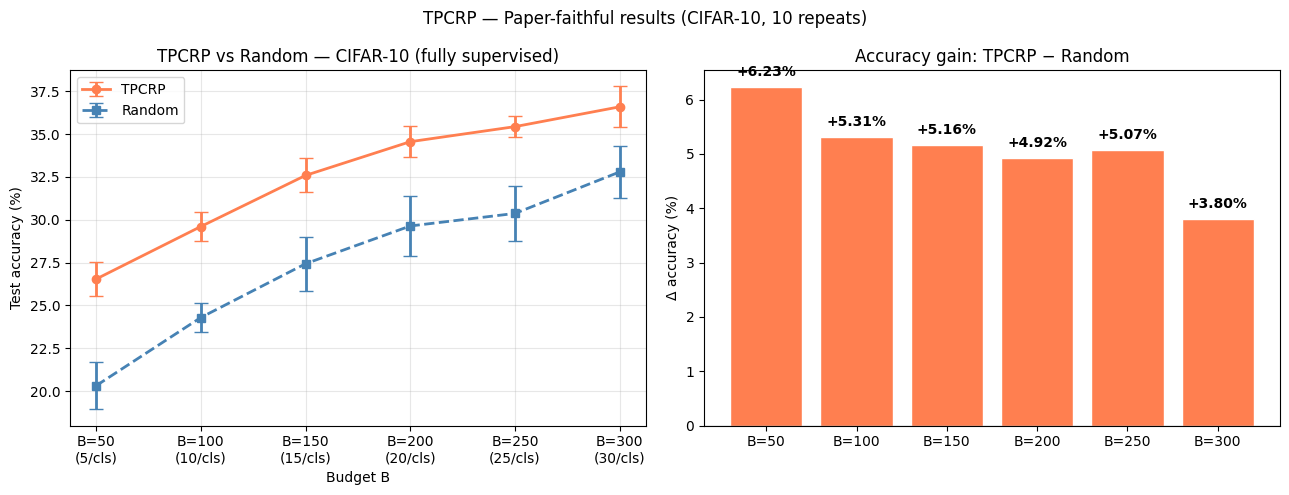

In [14]:
tpcrp_means = [np.mean(results[b]["tpcrp"]) for b in BUDGETS]
random_means = [np.mean(results[b]["random"]) for b in BUDGETS]
tpcrp_std = [np.std(results[b]["tpcrp"]) for b in BUDGETS]
random_std = [np.std(results[b]["random"]) for b in BUDGETS]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.errorbar(
    BUDGETS,
    tpcrp_means,
    yerr=tpcrp_std,
    fmt="o-",
    color="coral",
    linewidth=2,
    capsize=5,
    label="TPCRP",
)
ax.errorbar(
    BUDGETS,
    random_means,
    yerr=random_std,
    fmt="s--",
    color="steelblue",
    linewidth=2,
    capsize=5,
    label="Random",
)
ax.set_xlabel("Budget B")
ax.set_ylabel("Test accuracy (%)")
ax.set_title("TPCRP vs Random — CIFAR-10 (fully supervised)")
ax.set_xticks(BUDGETS)
ax.set_xticklabels([f"B={b}\n({b//10}/cls)" for b in BUDGETS])
ax.legend()
ax.grid(alpha=0.3)

ax2 = axes[1]
gains = [t - r for t, r in zip(tpcrp_means, random_means)]
colors = ["coral" if g >= 0 else "steelblue" for g in gains]
ax2.bar([f"B={b}" for b in BUDGETS], gains, color=colors, edgecolor="white")
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_title("Accuracy gain: TPCRP − Random")
ax2.set_ylabel("Δ accuracy (%)")
for i, g in enumerate(gains):
    ax2.text(
        i,
        g + 0.2 * (1 if g >= 0 else -1),
        f"{g:+.2f}%",
        ha="center",
        fontsize=10,
        fontweight="bold",
    )

plt.suptitle("TPCRP — Paper-faithful results (CIFAR-10, 10 repeats)", fontsize=12)
plt.tight_layout()
plt.savefig("./tpcrp_results_corrected_from50_to_300.png", dpi=150, bbox_inches="tight")
plt.show()


In [15]:
print("results:")
for b in BUDGETS:
    t = np.mean(results[b]["tpcrp"])
    r = np.mean(results[b]["random"])
    print(f"  B={b}: tpcrp={t:.2f}%  random={r:.2f}%  gain={t-r:+.2f}%")



══════════════════════════════════════════════════════════════
  TPCRP — FINAL RESULTS (PAPER-FAITHFUL IMPLEMENTATION)
  Hacohen et al., "Active Learning on a Budget", ICML 2022
══════════════════════════════════════════════════════════════
  Dataset                       : CIFAR-10  (50,000 train / 10,000 test)
  Representation                : SimCLR ResNet-18, 500 epochs, batch=512
  Embedding                     : 512-d L2-normalised (penultimate layer)
  Typicality                    : Global k-NN, k=20 (Equation 4)
  Clustering                    : K-means, K=min(B, 500)
  Classifier                    : ResNet-18, SGD+Nesterov, cosine LR=0.025
  Clf epochs                    : 200
  Weight decay                  : 0.0005
  Repeats                       : 10
──────────────────────────────────────────────────────────────
    Budget  Approx/cls           TPCRP          Random      Gain
──────────────────────────────────────────────────────────────
  B=  50          5/cls   26.54% 